In [1]:
import numpy as np
import math
from sympy import *
from scipy import integrate
import matplotlib.pyplot as plt
import random
import time

In [2]:
def TDT(b,c):
    if b+c == 0:
        return 0
    else:
        return ((b-c)**2)/(b+c)

In [3]:
def LS(b,c,N): 
    stat = TDT(b,c)
    M = stat; m = stat
    
    if b >= 2:
        v = [TDT(b-2,c), TDT(b-2,c+1), TDT(b-2,c+2)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b >= 1:
        v = [TDT(b-1,c), TDT(b-1,c+1)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b >= 1 and c >= 1:
        v = TDT(b-1,c-1)
        M = max([v,M])
        m = min([v,m])
    if c >= 2:
        v = [TDT(b,c-2), TDT(b+1,c-2), TDT(b+2,c-2)]
        M = max([max(v),M])
        m = min([min(v),m])
    if c >= 1:
        v = [TDT(b,c-1), TDT(b+1,c-1)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b+c <= 2*N-2:
        v = [TDT(b+1,c+1), TDT(b,c+2), TDT(b+2,c)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b+c <= 2*N-1:
        v = [TDT(b,c+1), TDT(b+1,c)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b+c <= 2*N-1 and b >= 1:
        v = TDT(b-1,c+2)
        M = max([v,M])
        m = min([v,m])
    if b+c <= 2*N-1 and c >= 1:
        v = TDT(b+2,c-1)
        M = max([v,M])
        m = min([v,m])
    
    return [M-stat, stat-m]

In [4]:
def h3_OS(z,zeta):
    if z < 0:
        return 0
    else:
        return (3*np.sqrt(3)*(zeta**(2/3)))/(2*math.pi*(math.fabs(z)**3+zeta))

def h4_OS(z,zeta):
    if z < 0:
        return 0
    else:
        return 2*np.sqrt(2)*(zeta**(3/4))/(math.pi*(z**4+zeta))
    
def h6_OS(z,zeta):
    if z < 0:
        return 0
    else:
        return (3*(zeta**(5/6)))/(math.pi*(z**6+zeta))
    
def h10_OS(z,zeta):
    if z < 0:
        return 0
    else:
        return (5*math.sqrt(5)-5)*(zeta**(9/10))/(2*math.pi*(z**10+zeta))

def cdf(x,h):
    return integrate.quad(h,-oo,x)

def noise(CDF):
    rr = np.random.rand()
    l = 0; r = 2000
    while(1):
        t = (int)((l+r)/2)
        if CDF[t] >= rr:
            r = t
        else:
            l = t
        if r-l <= 1:
            z = (((l+r)/2)-1000)/100
            break
    return z

def EDOSPS(x,eps,N,m,gamma,zeta,CDF): #M_{EDOSPS}, ud(x), One-Sided noise #N = 150
    GS = 2*(8*(N-1)/N); lbeta = math.log(GS/(max(LS(42,258,N))+max(LS(135,165,N))))/27 #math.log(GS/(2*max(LS(91,209,N))))/27
    alpha = (zeta**(1/gamma))*eps/(2*((gamma-1)**((gamma-1)/gamma)))
    beta = eps/(2*(gamma-1)); lbeta = min(lbeta,beta/(m/(gamma-1)))
    k = 1 - m*lbeta/(2*(gamma-1)*beta)
    u = np.zeros(m); v = np.zeros(m)
    s = np.zeros(m)
    
    flag = 0; sd = 10000
    for i in range(m):
        u[i] = TDT(x[i][0],x[i][1])
        b1 = x[i][0]; c1 = x[i][1]
        ls1 = LS(b1,c1,N); ls10 = ls1[0]; ls11 = ls1[1]
        for j in range(i+1,m):
            b2 = x[j][0]; c2 = x[j][1]
            ls2 = LS(b2,c2,N); ls20 = ls2[0]; ls21 = ls2[1]
            if ls10 + ls21 > 12 or ls11 + ls20 > 12:
                flag = 1; break
            else:
                sd = min([math.ceil((12-ls10-ls21)*(b1+c1)*(b2+c2)/(32*(b1+c1+b2+c2)))+1, math.ceil((12-ls11-ls20)*(b1+c1)*(b2+c2)/(32*(b1+c1+b2+c2)))+1, sd])
                
    if flag == 1:
        S = GS
    else:
        S = GS*math.exp(-lbeta*sd)
            
    for i in range(m):
        v[i] = u[i] + (S/(2*k*alpha))*noise(CDF)
    
    return np.argmax(v)

In [5]:
def generateData(N):
    d = np.zeros(2)
    s = np.random.binomial(int(2*N),2/3)
    d[0] = np.random.binomial(s,1/2)
    d[1] = s-d[0]
    return d

In [6]:
def accuracy(N,m,eps,zeta,CDF_OS_2,CDF_OS_4,CDF_OS_6,CDF_OS_10):
    acc = np.zeros((6,4))
    x = np.zeros((m,2)); stats = np.zeros((m,2))
    
    for j in range(100):
        for i in range(m):
            x[i] = generateData(N)
            stats[i][0] = TDT(x[i][0],x[i][1])
            stats[i][1] = i
        sstats = sorted(stats,key=lambda x:(x[0]),reverse=True)
        sx = np.zeros((m,2))
        for i in range(m):
            sx[i] = x[int(sstats[i][1])]
        
        for j in range(6):
            a = EDOSPS(sx,eps,N,m,3,zeta[j],CDF_OS_3[j]); b = EDOSPS(sx,eps,N,m,4,zeta[j],CDF_OS_4[j])
            c = EDOSPS(sx,eps,N,m,6,zeta[j],CDF_OS_6[j]); d = EDOSPS(sx,eps,N,m,10,zeta[j],CDF_OS_10[j])
            if a == 0:
                acc[j][0] += 1
            if b == 0:
                acc[j][1] += 1
            if c == 0:
                acc[j][2] += 1
            if d == 0:
                acc[j][3] += 1
    return acc/100

[[0.7  0.84 0.79 0.77]
 [0.72 0.84 0.9  0.72]
 [0.84 0.9  0.87 0.79]
 [0.82 0.78 0.86 0.75]
 [0.82 0.87 0.79 0.76]
 [0.81 0.85 0.81 0.77]]
[[0.85 0.9  0.82 0.78]
 [0.81 0.85 0.84 0.88]
 [0.8  0.89 0.84 0.75]
 [0.86 0.82 0.82 0.72]
 [0.82 0.84 0.8  0.86]
 [0.86 0.84 0.87 0.77]]
[[0.78 0.88 0.89 0.76]
 [0.84 0.9  0.9  0.76]
 [0.86 0.88 0.86 0.78]
 [0.81 0.87 0.82 0.76]
 [0.85 0.94 0.89 0.83]
 [0.84 0.9  0.89 0.73]]
[[0.85 0.85 0.86 0.82]
 [0.78 0.88 0.84 0.74]
 [0.83 0.86 0.83 0.75]
 [0.82 0.89 0.79 0.78]
 [0.84 0.9  0.89 0.73]
 [0.84 0.84 0.84 0.89]]
[[0.77 0.81 0.8  0.75]
 [0.72 0.85 0.84 0.72]
 [0.83 0.8  0.82 0.75]
 [0.86 0.76 0.8  0.82]
 [0.84 0.84 0.82 0.8 ]
 [0.82 0.86 0.82 0.8 ]]
[[0.79  0.856 0.832 0.776]
 [0.774 0.864 0.864 0.764]
 [0.832 0.866 0.844 0.764]
 [0.834 0.824 0.818 0.766]
 [0.834 0.878 0.838 0.796]
 [0.834 0.858 0.846 0.792]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


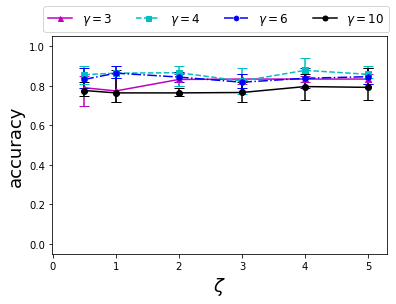

In [7]:
N = 150; m = 15; eps = 21

acc = np.zeros((6,4))
max_acc = np.zeros((6,4)); min_acc = np.ones((6,4))
sum_acc = np.zeros((6,4))

zeta = [0.5,1,2,3,4,5]
y_err = np.zeros((2,6,4))

CDF_OS_3 = np.zeros((6,2001))
for j in range(6):
    for i in range(2001):
        CDF_OS_3[j][i] = cdf((i-1000)/100,(lambda z: h3_OS(z,zeta[j])))[0]
    
CDF_OS_4 = np.zeros((6,2001))
for j in range(6):
    for i in range(2001):
        CDF_OS_4[j][i] = cdf((i-1000)/100,(lambda z: h4_OS(z,zeta[j])))[0]
            
CDF_OS_6 = np.zeros((6,2001))
for j in range(6):
    for i in range(2001):
        CDF_OS_6[j][i] = cdf((i-1000)/100,(lambda z: h6_OS(z,zeta[j])))[0]
            
CDF_OS_10 = np.zeros((6,2001))
for j in range(6):
    for i in range(2001):
        CDF_OS_10[j][i] = cdf((i-1000)/100,(lambda z: h10_OS(z,zeta[j])))[0]
        
for j in range(5):
    acc = accuracy(N,m,eps,zeta,CDF_OS_3,CDF_OS_4,CDF_OS_6,CDF_OS_10)
    for i in range(6):
        for k in range(4):
            max_acc[i][k] = max(max_acc[i][k], acc[i][k])
            min_acc[i][k] = min(min_acc[i][k], acc[i][k])
            sum_acc[i][k] += acc[i][k]
    print(acc)
acc = sum_acc/5

for k in range(4):
    y_err[0,:,k] = acc[:,k] - min_acc[:,k]
    y_err[1,:,k] = max_acc[:,k] - acc[:,k]

print(acc)
fig = plt.figure()
plt.ylim(-0.05, 1.05)
plt.xlim(-0.01, 5.3)
plt.errorbar(zeta, acc[:,0], yerr = y_err[:,:,0], capsize=5, fmt='^', ecolor='m', markeredgecolor = "m", color='m')
plt.plot(zeta, acc[:,0], marker="^", markersize=5, color = "m", linestyle = "-", label = "$\gamma = 3$")
plt.errorbar(zeta, acc[:,1], yerr = y_err[:,:,1], capsize=5, fmt='s', ecolor='c', markeredgecolor = "c", color='c')
plt.plot(zeta, acc[:,1], marker="s", markersize=5, color = "c", linestyle = "--", label = "$\gamma = 4$")
plt.errorbar(zeta, acc[:,2], yerr = y_err[:,:,2], capsize=5, fmt='h', ecolor='blue', markeredgecolor = "blue", color='blue')
plt.plot(zeta, acc[:,2], marker="h", markersize=5, color = "blue", linestyle = "dashdot", label = "$\gamma = 6$")
plt.errorbar(zeta, acc[:,3], yerr = y_err[:,:,3], capsize=5, fmt='o', ecolor='black', markeredgecolor = "black", color='black')
plt.plot(zeta, acc[:,3], marker="o", markersize=5, color = "black", linestyle = "-", label = "$\gamma = 10$")
plt.legend(bbox_to_anchor=(0.49, 1.02), loc='lower center', borderaxespad=0, ncol=4, fontsize=12)
plt.xlabel("$\zeta$", fontsize = 18)
plt.ylabel("accuracy", fontsize = 18)
fig.savefig("Accuracy_gammazeta_m=15_eps=21.png")
fig.savefig("figs/Accuracy_gammazeta_m=15_eps=21.eps", bbox_inches="tight", pad_inches=0.05)